# Why CNN Alone Doesn't Work Well for OCR

## The Problem with Traditional CNNs for Text Recognition

CNNs are excellent at **spatial feature extraction** but have fundamental limitations when dealing with **sequential data** like text.

### Key Issues:

1. **Fixed Input Size**: CNNs require fixed-size inputs, but text has variable lengths
2. **No Sequence Modeling**: CNNs don't understand character order or dependencies
3. **Character Segmentation**: Need to know where each character starts and ends
4. **Spatial vs Sequential**: Text is fundamentally a 1D sequence in 2D space

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Let's create a simple CNN classifier to demonstrate the limitations
class SimpleCNN(nn.Module):
    """A simple CNN for single character classification"""

    def __init__(self, num_classes=26):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)  # Assumes 32x32 input
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Create the model
model = SimpleCNN(num_classes=26)  # 26 letters
print("Simple CNN Architecture:")
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Simple CNN Architecture:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=26, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Total parameters: 623898


## Problem 1: Fixed Input Size

CNNs require fixed-size inputs, but text images have variable lengths:
- "Hi" vs "Hello World" have different widths
- Traditional approach: resize all images to same size
- **Issue**: Distorts character proportions and spacing

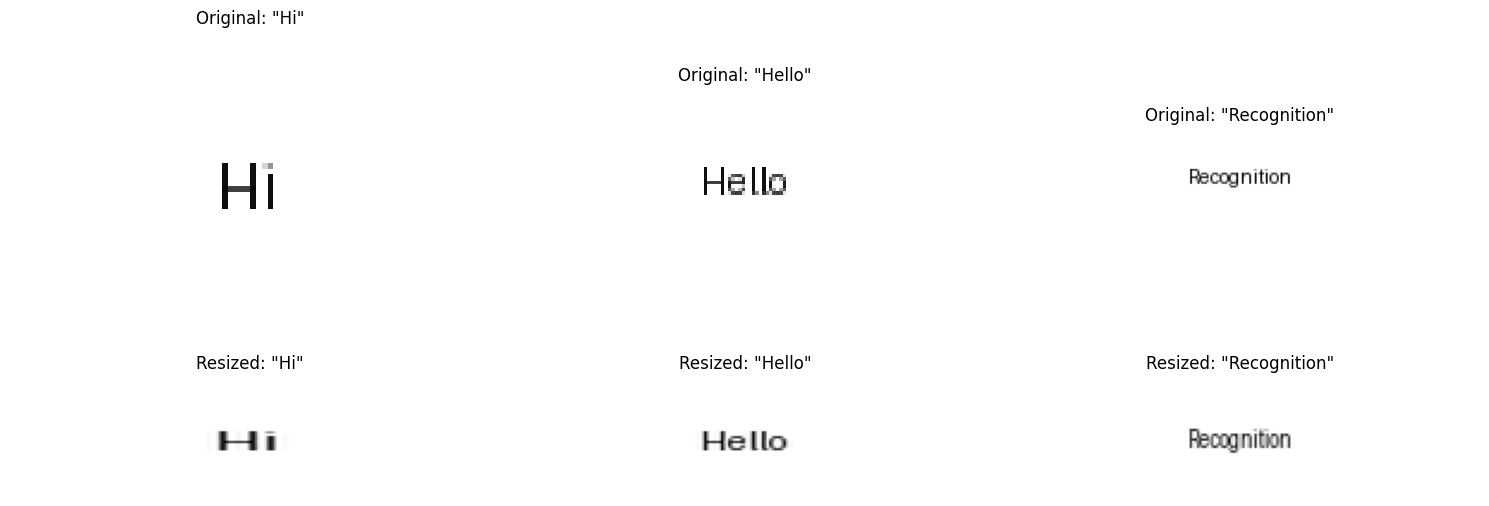

Notice how resizing distorts the text:
- Short words get stretched horizontally
- Long words get compressed
- Character proportions are lost
- This makes it harder for CNN to learn consistent features


In [2]:
# Demonstrate the fixed input size problem

def create_text_image(text, size=(200, 50), font_size=20):
    """Create a text image with proper sizing"""
    img = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (size[0] - text_width) // 2
    y = (size[1] - text_height) // 2

    draw.text((x, y), text, fill='black', font=font)
    return img

# Create text images of different lengths
texts = ["Hi", "Hello", "Recognition"]
original_images = []
resized_images = []

for text in texts:
    # Create image with natural size
    natural_width = len(text) * 20 + 40  # Rough estimate
    original_img = create_text_image(text, size=(natural_width, 50), font_size=20)
    original_images.append(original_img)

    # Resize to fixed size (what CNN requires)
    fixed_size_img = original_img.resize((200, 50), Image.LANCZOS)
    resized_images.append(fixed_size_img)

# Display comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for i, (text, orig_img, resized_img) in enumerate(zip(texts, original_images, resized_images)):
    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f'Original: "{text}"')
    axes[0, i].axis('off')

    axes[1, i].imshow(resized_img)
    axes[1, i].set_title(f'Resized: "{text}"')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("Notice how resizing distorts the text:")
print("- Short words get stretched horizontally")
print("- Long words get compressed")
print("- Character proportions are lost")
print("- This makes it harder for CNN to learn consistent features")

## Problem 2: Character Segmentation

Traditional CNN approach requires knowing where each character begins and ends:
- Need to segment "HELLO" into "H", "E", "L", "L", "O"
- **Challenge**: Characters may be connected, overlapping, or have varying spacing
- **Solution Attempt**: Sliding window approach
- **New Problem**: How to determine optimal window size and step?

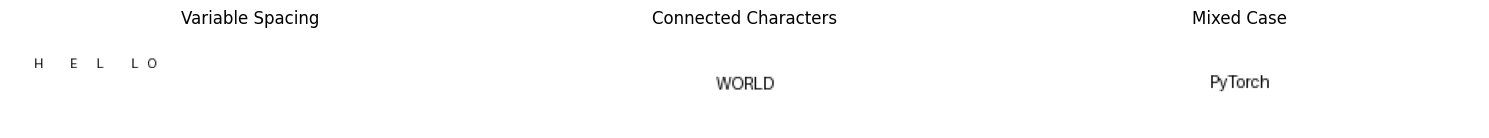

Segmentation Challenges:
1. Variable spacing between characters
2. Connected or overlapping characters
3. Different font sizes and styles
4. Cursive or handwritten text

Traditional CNN approach: Manually segment each character
Problem: Segmentation errors propagate to recognition errors


In [3]:
# Demonstrate character segmentation challenges

def create_challenging_text_image(text, size=(400, 80)):
    """Create text with challenging segmentation scenarios"""
    img = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 32)
    except:
        font = ImageFont.load_default()

    # Add some random spacing variations
    x_pos = 20
    for i, char in enumerate(text):
        # Vary spacing randomly
        if i > 0:
            spacing = np.random.randint(5, 25)
            x_pos += spacing

        draw.text((x_pos, 20), char, fill='black', font=font)

        # Get character width for next position
        bbox = draw.textbbox((0, 0), char, font=font)
        char_width = bbox[2] - bbox[0]
        x_pos += char_width

    return img

# Create examples with different segmentation challenges
challenges = {
    "Variable Spacing": create_challenging_text_image("HELLO"),
    "Connected Characters": create_text_image("WORLD", size=(300, 60), font_size=32),
    "Mixed Case": create_text_image("PyTorch", size=(300, 60), font_size=32)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (title, img) in enumerate(challenges.items()):
    axes[i].imshow(img)
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Segmentation Challenges:")
print("1. Variable spacing between characters")
print("2. Connected or overlapping characters")
print("3. Different font sizes and styles")
print("4. Cursive or handwritten text")
print("\nTraditional CNN approach: Manually segment each character")
print("Problem: Segmentation errors propagate to recognition errors")

## Problem 3: No Sequence Understanding

CNNs process images as independent spatial patterns but text has sequential dependencies:
- "THE" vs "ETH" - same letters, different meaning
- Context matters: "ROAD" vs "ROAR" (one character difference)
- Language patterns: "QU" commonly appears together
- **CNN Limitation**: Treats each position independently

In [4]:
# Demonstrate sequence understanding problem

def simulate_cnn_character_classification(text):
    """Simulate how CNN would classify each character independently"""
    # Create individual character images
    char_images = []
    char_predictions = []

    for char in text:
        # Create image for single character
        char_img = create_text_image(char, size=(50, 50), font_size=24)
        char_images.append(char_img)

        # Simulate CNN prediction (with some noise)
        # In reality, this would be actual CNN forward pass
        confidence = np.random.uniform(0.7, 0.95)
        char_predictions.append((char, confidence))

    return char_images, char_predictions

# Test with confusing examples
test_words = ["THE", "TEH", "ROAD", "ROAR"]

for word in test_words:
    char_imgs, predictions = simulate_cnn_character_classification(word)

    print(f"\nWord: {word}")
    print("CNN predictions (character-by-character):")
    for char, conf in predictions:
        print(f"  '{char}': {conf:.2f} confidence")

    # Show that CNN can't distinguish between valid/invalid sequences
    avg_confidence = np.mean([conf for _, conf in predictions])
    print(f"  Average confidence: {avg_confidence:.2f}")
    print(f"  Valid English word: {'THE' in word or 'ROAD' in word}")

print("\n" + "="*50)
print("Key Insight: CNN gives similar confidence to:")
print("- 'THE' (valid English word)")
print("- 'TEH' (typo/invalid sequence)")
print("\nCNN lacks sequence understanding!")


Word: THE
CNN predictions (character-by-character):
  'T': 0.84 confidence
  'H': 0.92 confidence
  'E': 0.84 confidence
  Average confidence: 0.87
  Valid English word: True

Word: TEH
CNN predictions (character-by-character):
  'T': 0.73 confidence
  'E': 0.71 confidence
  'H': 0.83 confidence
  Average confidence: 0.76
  Valid English word: False

Word: ROAD
CNN predictions (character-by-character):
  'R': 0.93 confidence
  'O': 0.92 confidence
  'A': 0.83 confidence
  'D': 0.91 confidence
  Average confidence: 0.90
  Valid English word: True

Word: ROAR
CNN predictions (character-by-character):
  'R': 0.71 confidence
  'O': 0.80 confidence
  'A': 0.73 confidence
  'R': 0.78 confidence
  Average confidence: 0.76
  Valid English word: False

Key Insight: CNN gives similar confidence to:
- 'THE' (valid English word)
- 'TEH' (typo/invalid sequence)

CNN lacks sequence understanding!


## Problem 4: Spatial vs Sequential Nature

### Text is fundamentally different from typical CNN tasks:

**Image Classification (CNN strength):**
- Object can appear anywhere in image
- Spatial relationships matter (wheel below car body)
- Translation invariance is desired

**Text Recognition (CNN weakness):**
- Character order is crucial
- Position matters: first letter vs last letter
- Need to preserve sequential information
- Translation invariance can be harmful

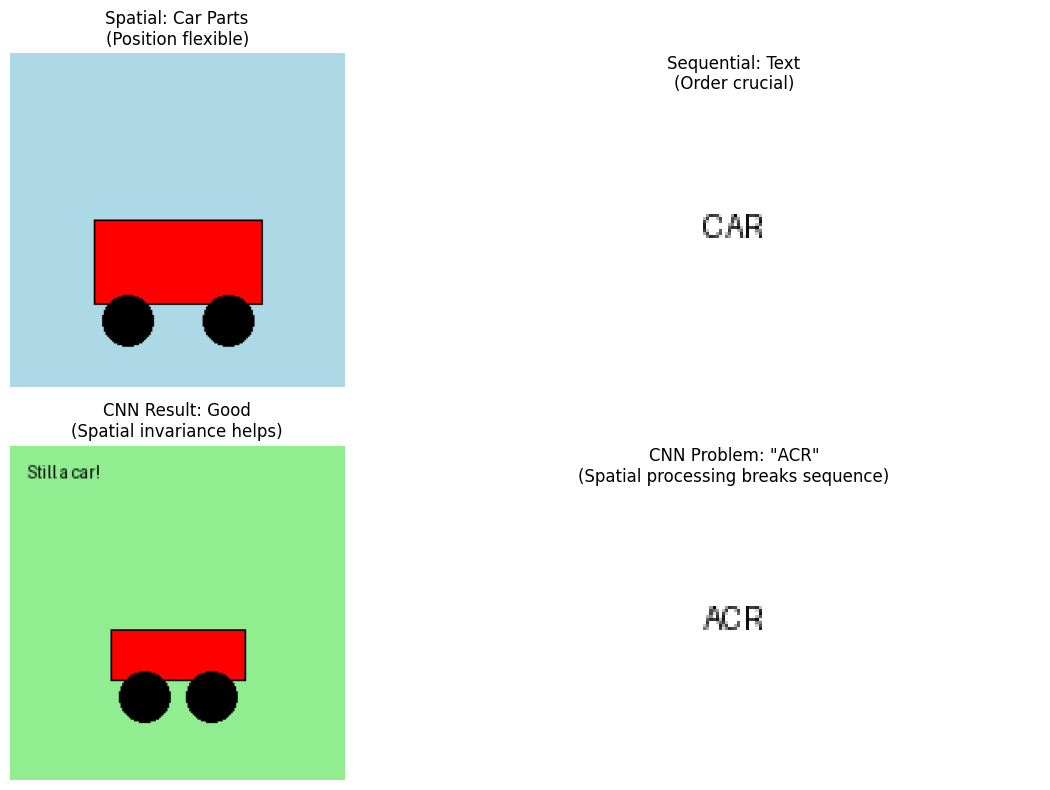

Key Differences:

Spatial Data (Images):
✓ CNN's spatial invariance is helpful
✓ Object parts can move without changing meaning
✓ Local features matter most

Sequential Data (Text):
✗ CNN's spatial invariance breaks sequence
✗ Character order changes meaning completely
✗ Global sequence context is crucial

SOLUTION: We need a hybrid approach!
CNN (spatial features) + RNN (sequence modeling) = CRNN


In [5]:
# Demonstrate spatial vs sequential processing

def create_spatial_vs_sequential_demo():
    """Show difference between spatial and sequential processing"""

    # Create images showing the difference
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Spatial: Object detection (car parts)
    spatial_img = Image.new('RGB', (200, 200), color='lightblue')
    draw = ImageDraw.Draw(spatial_img)
    # Draw simple car
    draw.rectangle([50, 100, 150, 150], fill='red', outline='black')
    draw.circle((70, 160), 15, fill='black')
    draw.circle((130, 160), 15, fill='black')
    axes[0, 0].imshow(spatial_img)
    axes[0, 0].set_title('Spatial: Car Parts\n(Position flexible)')
    axes[0, 0].axis('off')

    # Sequential: Text
    text_img = create_text_image("CAR", size=(200, 80), font_size=32)
    axes[0, 1].imshow(text_img)
    axes[0, 1].set_title('Sequential: Text\n(Order crucial)')
    axes[0, 1].axis('off')

    # Show what happens with CNN processing

    # CNN on spatial data - works well
    spatial_processed = Image.new('RGB', (200, 200), color='lightgreen')
    draw2 = ImageDraw.Draw(spatial_processed)
    draw2.rectangle([60, 110, 140, 140], fill='red', outline='black')
    draw2.circle((80, 150), 15, fill='black')
    draw2.circle((120, 150), 15, fill='black')
    draw2.text((10, 10), "Still a car!", fill='black')
    axes[1, 0].imshow(spatial_processed)
    axes[1, 0].set_title('CNN Result: Good\n(Spatial invariance helps)')
    axes[1, 0].axis('off')

    # CNN on sequential data - problems
    scrambled_img = create_text_image("ACR", size=(200, 80), font_size=32)
    axes[1, 1].imshow(scrambled_img)
    axes[1, 1].set_title('CNN Problem: "ACR"\n(Spatial processing breaks sequence)')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

create_spatial_vs_sequential_demo()

print("Key Differences:")
print("\nSpatial Data (Images):")
print("✓ CNN's spatial invariance is helpful")
print("✓ Object parts can move without changing meaning")
print("✓ Local features matter most")

print("\nSequential Data (Text):")
print("✗ CNN's spatial invariance breaks sequence")
print("✗ Character order changes meaning completely")
print("✗ Global sequence context is crucial")

print("\n" + "="*50)
print("SOLUTION: We need a hybrid approach!")
print("CNN (spatial features) + RNN (sequence modeling) = CRNN")

## Summary: Why CNNs Alone Fail at OCR

### The Four Key Problems:

1. **Fixed Input Requirement**: Text has variable lengths, CNN needs fixed sizes
2. **Character Segmentation**: Manual segmentation is error-prone and brittle
3. **No Sequence Understanding**: Can't distinguish valid from invalid letter sequences
4. **Spatial vs Sequential**: CNN's spatial invariance breaks text's sequential nature

### What We Need:
- **Spatial Feature Extraction**: CNN's strength for recognizing character shapes
- **Sequence Modeling**: RNN's ability to understand character order
- **Alignment Learning**: Automatic way to align features with characters
- **Variable Length Handling**: Support for any text length

### The Solution: CRNN (Convolutional Recurrent Neural Network)
Coming up next: How CRNN combines the best of both worlds!